# Importing the data

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder


df = pd.read_excel('/content/student_data_final.xlsx')

print("Sample of data:\n", df.head())

Sample of data:
   assessment_type  weight  date_submitted  score  date_registration gender  \
0             TMA    10.0              18     78             -159.0      M   
1             TMA    10.0              22     70              -53.0      F   
2             TMA    10.0              17     72              -52.0      F   
3             TMA    10.0              26     69             -176.0      F   
4             TMA    10.0              19     79             -110.0      M   

                 region      highest_education imd_band age_band  \
0   East Anglian Region       HE Qualification  90-100%     55<=   
1              Scotland       HE Qualification   20-30%    35-55   
2     South East Region  A Level or Equivalent   50-60%    35-55   
3  West Midlands Region     Lower Than A Level   50-60%     0-35   
4                 Wales  A Level or Equivalent   80-90%    35-55   

   num_of_prev_attempts  studied_credits disability  \
0                     0              240          

In [ ]:

column_names = df.columns.tolist()

print(column_names)

['assessment_type', 'weight', 'date_submitted', 'score', 'date_registration', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'module_presentation_length', 'final_result']


# Encoding of data

In [ ]:

df1=df.copy()

categorical_cols = ['assessment_type', 'gender', 'region', 'highest_education',
                    'imd_band', 'age_band', 'disability', 'final_result']

# Initializing label encoder
le = LabelEncoder()


for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])


print("\nEncoded data sample:\n", df1.head())



Encoded data sample:
    assessment_type  weight  date_submitted  score  date_registration  gender  \
0                2    10.0              18     78             -159.0       1   
1                2    10.0              22     70              -53.0       0   
2                2    10.0              17     72              -52.0       0   
3                2    10.0              26     69             -176.0       0   
4                2    10.0              19     79             -110.0       1   

   region  highest_education  imd_band  age_band  num_of_prev_attempts  \
0       0                  1         9         2                     0   
1       6                  1         2         1                     0   
2       7                  0         5         1                     0   
3      11                  2         5         0                     0   
4      10                  0         8         1                     0   

   studied_credits  disability  module_presentation

# Data Preprocessing

In [ ]:

correlation_matrix = df1.corr()

print(correlation_matrix)

                            assessment_type    weight  date_submitted  \
assessment_type                    1.000000  0.523318       -0.318788   
weight                             0.523318  1.000000        0.126908   
date_submitted                    -0.318788  0.126908        1.000000   
score                             -0.221942 -0.167892       -0.021695   
date_registration                 -0.029546 -0.043967        0.031384   
gender                            -0.011533  0.073132       -0.001692   
region                             0.008208  0.003459       -0.008840   
highest_education                 -0.014446 -0.038987       -0.005357   
imd_band                           0.005828  0.038326        0.009820   
age_band                          -0.007692 -0.017047       -0.004101   
num_of_prev_attempts               0.009975  0.000013       -0.053862   
studied_credits                    0.020258  0.050109       -0.056771   
disability                        -0.006646 -0.0201

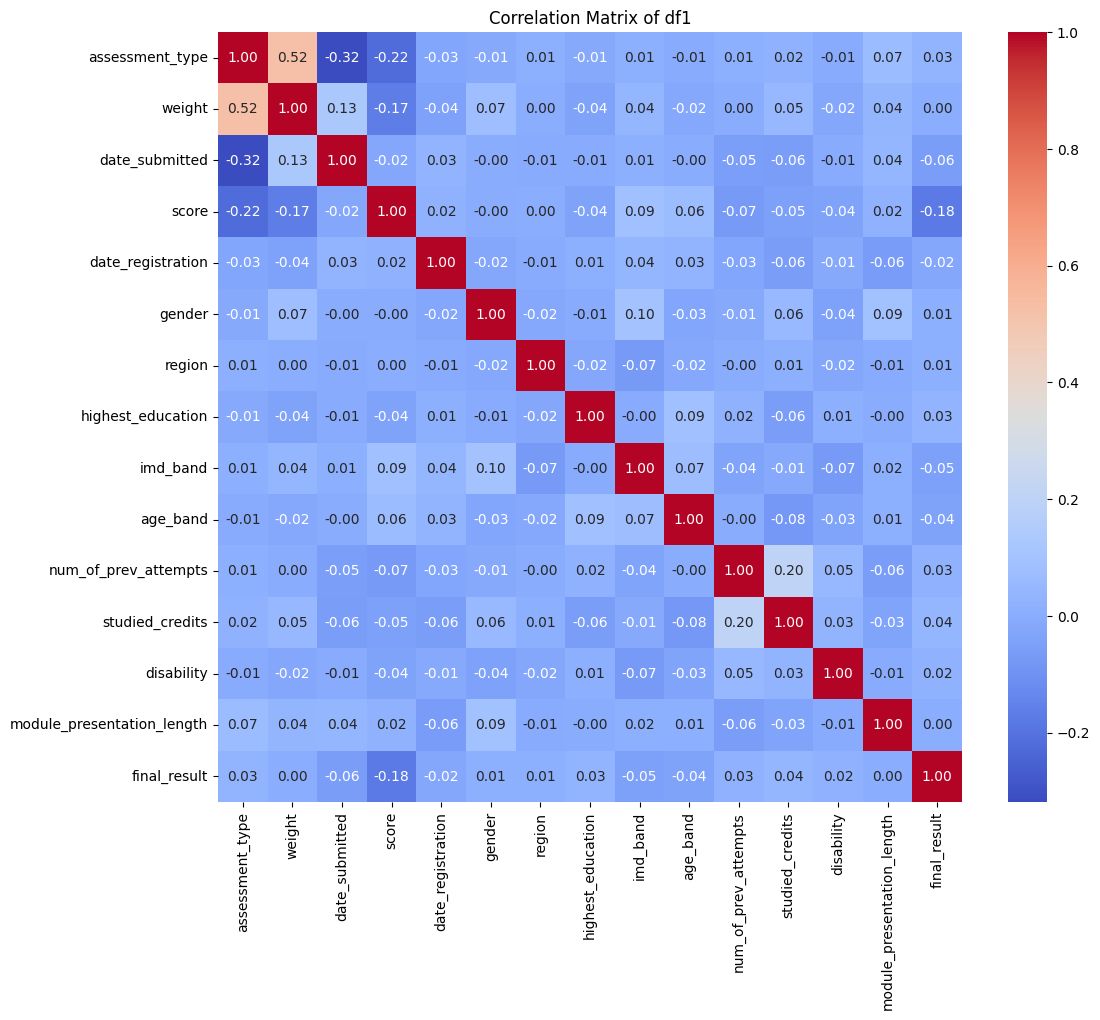

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


correlation_matrix = df1.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of df1")
plt.show()

In [ ]:

columns_with_nulls = df1.columns[df1.isnull().any()].tolist()


print(columns_with_nulls)

['date_registration']


In [ ]:

correlation_matrix = df1.corr()


date_registration_correlations = correlation_matrix['date_registration']


sorted_correlations = date_registration_correlations.sort_values(ascending=False)


print(sorted_correlations.head(10))  # Print top 10, adjust as needed

date_registration    1.000000
imd_band             0.039478
date_submitted       0.031384
age_band             0.029705
score                0.016325
highest_education    0.014652
region              -0.007192
disability          -0.010334
gender              -0.020563
final_result        -0.020640
Name: date_registration, dtype: float64


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df1[['final_result']]
y = df1['date_registration']


X_train = X[y.notnull()]
y_train = y[y.notnull()]


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X)


r2 = r2_score(y_train, model.predict(X_train))


print(f"R-squared: {r2}")

R-squared: 0.00042602713447637


Imputing null values

In [ ]:
# Imputing null values in 'date_registration' using predicted values
df1.loc[df1['date_registration'].isnull(), 'date_registration'] = y_pred[df1['date_registration'].isnull()]

In [ ]:

null_counts = df1.isnull().sum()


print(null_counts)

assessment_type               0
weight                        0
date_submitted                0
score                         0
date_registration             0
gender                        0
region                        0
highest_education             0
imd_band                      0
age_band                      0
num_of_prev_attempts          0
studied_credits               0
disability                    0
module_presentation_length    0
final_result                  0
dtype: int64


# Feature Selection

In [ ]:
import pandas as pd
import statsmodels.api as sm
from itertools import combinations

def feature_selection_combinations(X, y, alpha=0.05):

    best_features = []
    best_p_values = []


    current_features = []


    for k in range(1, len(X.columns) + 1):
        for feature_subset in combinations(X.columns, k):

            features_to_test = current_features + list(feature_subset)


            X_subset = X[features_to_test]


            X_subset = sm.add_constant(X_subset)


            model = sm.OLS(y, X_subset).fit()


            p_values = model.pvalues[len(current_features) + 1:]


            if all(p < alpha for p in p_values):
                current_features = features_to_test
                best_p_values.extend(p_values)


    best_features = current_features

    return best_features, best_p_values


selected_features, selected_p_values = feature_selection_combinations(X_train, y_train)
print("Selected Features:", selected_features)
print("Selected Features' p-values:", selected_p_values)


X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]


# Model Selection

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


X = df1.drop('final_result', axis=1)  # Features
y = df1['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f'{model_name}: Accuracy = {accuracy:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, F1-score = {f1:.4f}')



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 0.6139, Precision = 0.5361, Recall = 0.6139, F1-score = 0.4956
Decision Tree: Accuracy = 0.5577, Precision = 0.5651, Recall = 0.5577, F1-score = 0.5612
Random Forest: Accuracy = 0.7146, Precision = 0.7077, Recall = 0.7146, F1-score = 0.6817
Gradient Boosting: Accuracy = 0.6375, Precision = 0.6070, Recall = 0.6375, F1-score = 0.5646


# Hyperparameter Tuning



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 5, 10],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 4)
}


random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)
random_search.fit(X_train, y_train)


best_model = random_search.best_estimator_
best_accuracy = random_search.best_score_

print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 157}
Best Accuracy: 0.6980


# Recommendation system

In [ ]:
def generate_recommendations(student_features):

  predicted_result = model.predict([student_features])[0]


  if predicted_result == 'Fail':
    recommendations = [ 'Explore additional study resources', 'Consult with an academic advisor']
  elif predicted_result == 'Pass':
    recommendations = ['Explore advanced courses in your field', 'Participate in extracurricular activities']
  else:
    recommendations = ['Apply for scholarships or research opportunities', 'Consider graduate studies']

  return recommendations


In [ ]:
def get_student_input(df1):

    features = {}


    categorical_cols = ['gender', 'region',
                        'highest_education', 'imd_band', 'age_band', 'disability']

    for col in categorical_cols:

        unique_values = df1[col].unique()
        encoded_values = {value: i for i, value in enumerate(unique_values)}


        print(f"Options for {col}:")
        for value, encoded_value in encoded_values.items():
            print(f"{encoded_value}: {value}")


        while True:
            try:
                user_input = int(input(f"Enter your choice for {col}: "))
                if user_input in encoded_values.values():
                    features[col] = user_input
                    break
                else:
                    print("Invalid choice. Please enter a valid option.")
            except ValueError:
                print("Invalid input. Please enter a number.")



    features['assessment_type'] = int(input("Enter assessment type (0-numeric, 1-TMA, 2-CMA, 3-Exam): "))
    features['date_registration'] = int(input("Enter date registration (days since a reference date): "))
    features['num_of_prev_attempts'] = int(input("Enter number of previous attempts: "))
    features['gender']=int(input("Enter Gender (0-Female, 1-Male): "))
    features['region']=int(input("Enter Region (0-North, 1-South, 2-East, 3-West): "))
    features['highest_education']=int(input("Enter Highest Education (0-No Qualification, 1-High School, 2-Bachelors, 3-Masters, 4-PhD): "))
    features['imd_band']=int(input("Enter IMD Band (0-0-1): "))
    features['age_band']=int(input("Enter Age Band (0-0-1): "))
    features['disability']=int(input("Enter Disability (0-No, 1-Yes): "))

    return features

In [ ]:
def main():

    student_features = get_student_input(df1)


    student_df = pd.DataFrame([student_features])


    predicted_result = model.predict(student_df)[0]


    recommendations = generate_recommendations(student_features)

    print(f"Predicted Final Result: {predicted_result}")
    print("Recommendations:")
    for recommendation in recommendations:
        print(f"- {recommendation}")

if __name__ == "__main__":
    main()